In [51]:
import pandas as pd

In [52]:
crimes_df = pd.read_csv('../crimes.csv')

In [53]:
crimes_df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST
...,...,...,...,...,...,...,...,...,...,...,...,...
185710,231510379,2023-05-29,2023-05-25,1100,N Hollywood,"BUNCO, GRAND THEFT",25,M,W,NaN,Invest Cont,5300 DENNY AV
185711,231604807,2023-01-27,2023-01-26,1800,Foothill,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23,M,H,NaN,Invest Cont,12500 BRANFORD ST
185712,231606525,2023-03-22,2023-03-22,1000,Foothill,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,12800 FILMORE ST
185713,231210064,2023-04-12,2023-04-12,1630,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,6100 S VERMONT AV


In [54]:
crimes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  int64 
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(3), object(9)
memory usage: 17.0+ MB


In [55]:
crimes_df.describe()

,DR_NO,TIME OCC,Vict Age
count,1.857150e+05,185715.000000,185715.000000
mean,2.255781e+08,1300.024414,39.999257
std,5.017438e+06,655.753163,15.450227
min,2.009072e+08,1.000000,2.000000
25%,2.210108e+08,830.000000,28.000000
50%,2.220114e+08,1340.000000,37.000000
75%,2.310044e+08,1830.000000,50.000000
max,2.399097e+08,2359.000000,99.000000


In [56]:
crimes_df.isna().sum()

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64

In [57]:
#convert dates to datetime
crimes_df["Date Rptd"] = pd.to_datetime(crimes_df["Date Rptd"])
crimes_df["DATE OCC"] = pd.to_datetime(crimes_df["DATE OCC"])

In [58]:
#handle missing values
crimes_df['Vict Sex'] = crimes_df['Vict Sex'].fillna("Unkown")
crimes_df["Vict Descent"] = crimes_df["Vict Descent"].fillna("Unkown")
crimes_df["Weapon Desc"] = crimes_df["Weapon Desc"].fillna("Unkown")

In [59]:
# #convert time OCC proper time format
# crimes_df["TIME OCC"] = crimes_df["TIME OCC"].apply(lambda x: f"{x:04}") 
# crimes_df["TIME OCC"] = pd.to_datetime(crimes_df["DATE OCC"].dt.date.astype(str) + ' ' + crimes_df['TIME OCC'].str[:2] + ':' + crimes_df['TIME OCC'].str[2:], format='%Y-%m-%d %H:%M', errors='coerce')

In [60]:
crimes_df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,Unkown,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,Unkown,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,Unkown,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,Unkown,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,Unkown,Invest Cont,1200 W 7TH ST
...,...,...,...,...,...,...,...,...,...,...,...,...
185710,231510379,2023-05-29,2023-05-25,1100,N Hollywood,"BUNCO, GRAND THEFT",25,M,W,Unkown,Invest Cont,5300 DENNY AV
185711,231604807,2023-01-27,2023-01-26,1800,Foothill,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23,M,H,Unkown,Invest Cont,12500 BRANFORD ST
185712,231606525,2023-03-22,2023-03-22,1000,Foothill,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,12800 FILMORE ST
185713,231210064,2023-04-12,2023-04-12,1630,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,6100 S VERMONT AV


In [61]:
crimes_df.isna().sum()

DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA NAME       0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Weapon Desc     0
Status Desc     0
LOCATION        0
dtype: int64

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

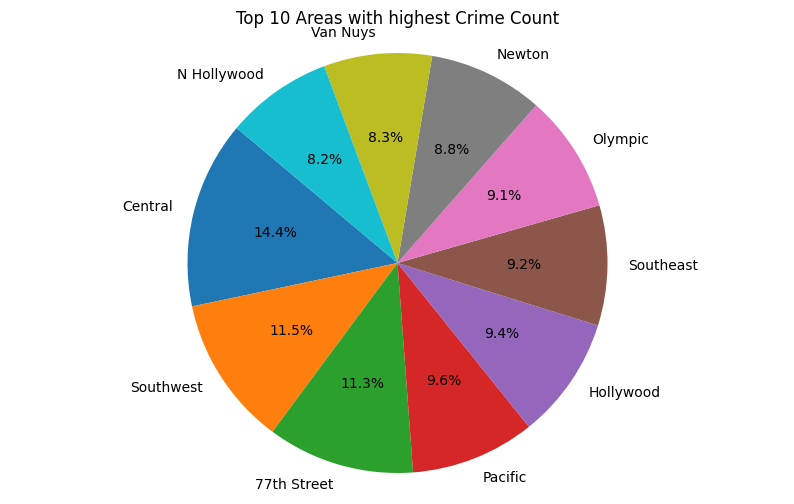

In [63]:
# Count crimes per area
area_counts = crimes_df['AREA NAME'].value_counts().reset_index()
area_counts.columns = ['AREA NAME', 'Crime Count']

# Plot top 10 areas
top10 = area_counts.head(10)

plt.figure(figsize=(10,6))
plt.pie(top10['Crime Count'], labels=top10['AREA NAME'], autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Areas with highest Crime Count')
plt.axis("equal")
plt.show()

/tmp/ipykernel_1259247/268518958.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=area_counts, x='Crime Count', y='AREA NAME', palette='viridis')


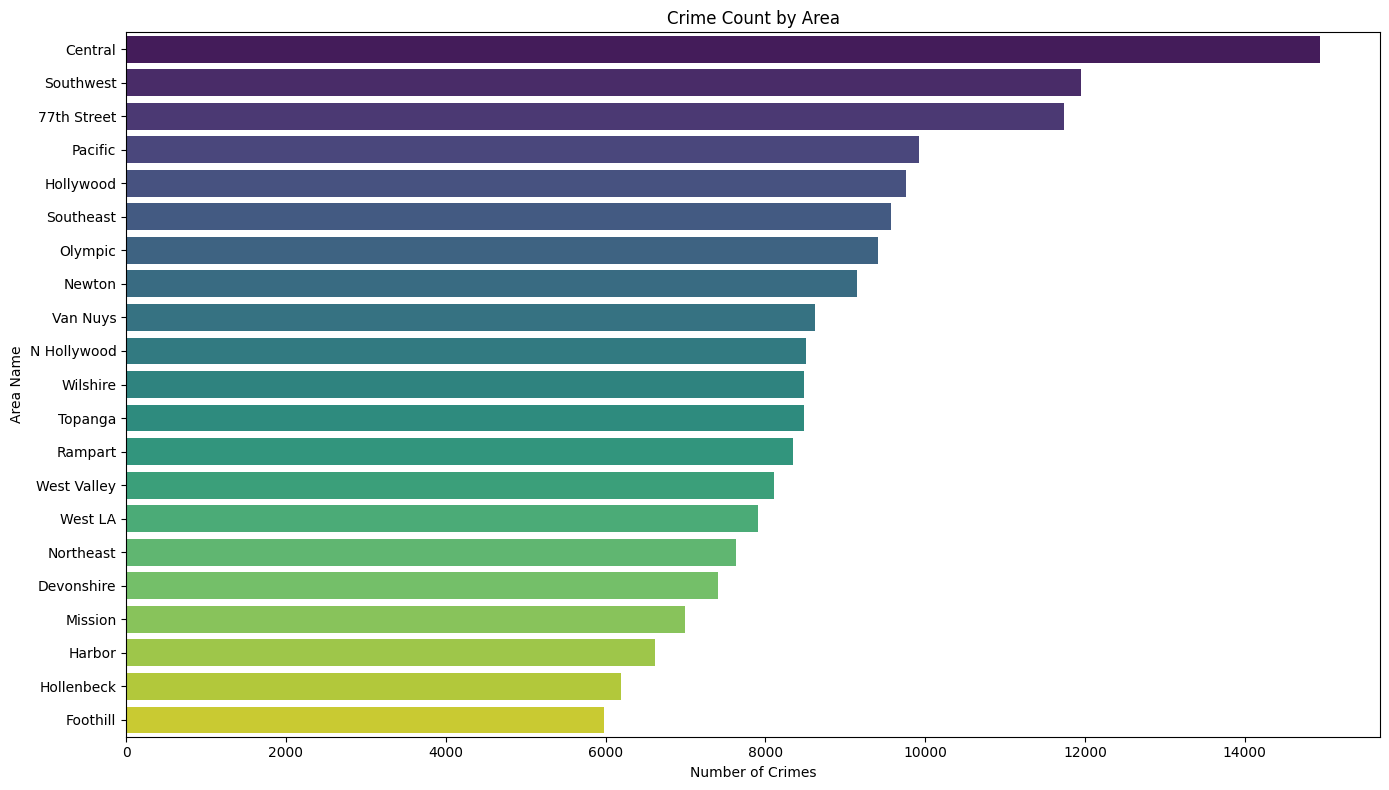

In [64]:
plt.figure(figsize=(14,8))
sns.barplot(data=area_counts, x='Crime Count', y='AREA NAME', palette='viridis')

plt.title("Crime Count by Area")
plt.xlabel("Number of Crimes")
plt.ylabel("Area Name")
plt.tight_layout()
plt.show()


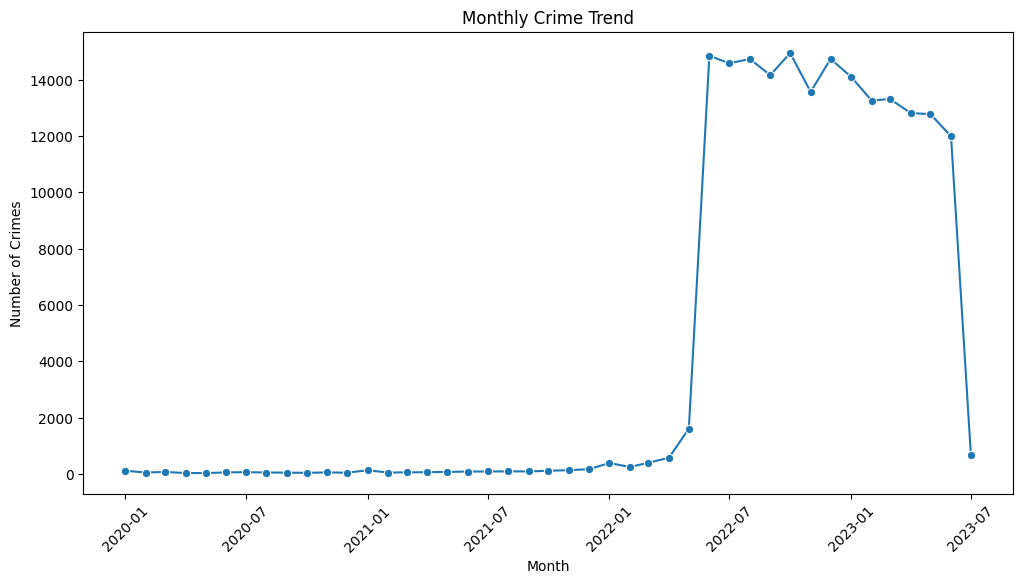

In [65]:
# Group by month (PeriodIndex)
monthly_crimes = crimes_df.groupby(crimes_df['DATE OCC'].dt.to_period('M')).size().reset_index(name='Crime Count')

# Convert PERIOD → TIMESTAMP
monthly_crimes['DATE OCC'] = monthly_crimes['DATE OCC'].dt.to_timestamp()

# Now plot
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_crimes, x='DATE OCC', y='Crime Count', marker='o')
plt.title('Monthly Crime Trend')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()


In [66]:
crime_counts = crimes_df['Crm Cd Desc'].value_counts().reset_index()
crime_counts.columns = ['Crime Type', 'Count']
crime_counts.head()


,Crime Type,Count
0,THEFT OF IDENTITY,22670
1,BATTERY - SIMPLE ASSAULT,19694
2,BURGLARY FROM VEHICLE,13799
3,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",13215
4,INTIMATE PARTNER - SIMPLE ASSAULT,11981


/tmp/ipykernel_1259247/398578107.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_crimes, x='Count', y='Crime Type', palette='mako')


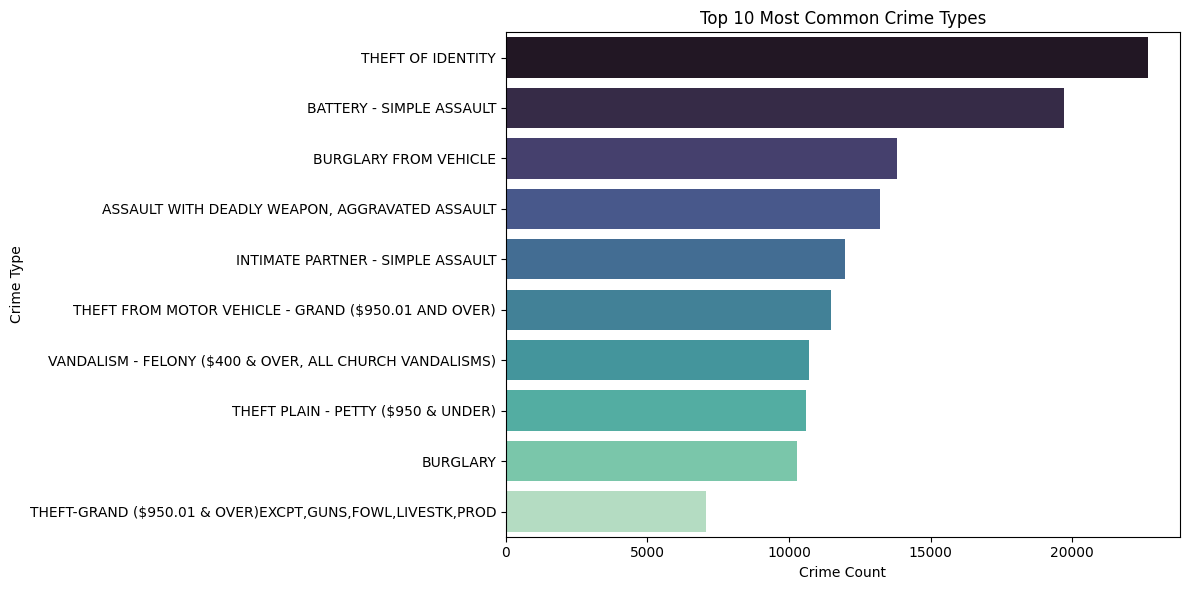

In [67]:
top10_crimes = crime_counts.head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top10_crimes, x='Count', y='Crime Type', palette='mako')

plt.title("Top 10 Most Common Crime Types")
plt.xlabel("Crime Count")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()

In [68]:
# Get crime count per area
area_counts = crimes_df['AREA NAME'].value_counts().reset_index()
area_counts.columns = ['AREA NAME', 'Crime Count']

# Top 10 areas
top10_areas = area_counts.head(10)['AREA NAME']
top10_areas


0        Central
1      Southwest
2    77th Street
3        Pacific
4      Hollywood
5      Southeast
6        Olympic
7         Newton
8       Van Nuys
9    N Hollywood
Name: AREA NAME, dtype: object

In [69]:
df_top10 = crimes_df[crimes_df['AREA NAME'].isin(top10_areas)]

In [70]:
top3_crimes_per_area = (
    df_top10.groupby(['AREA NAME', 'Crm Cd Desc'])
            .size()
            .reset_index(name='Count')
            .sort_values(['AREA NAME', 'Count'], ascending=[True, False])
)

# Select top 3 per area
top3_crimes_per_area = top3_crimes_per_area.groupby('AREA NAME').head(3)
top3_crimes_per_area


,AREA NAME,Crm Cd Desc,Count
58,77th Street,THEFT OF IDENTITY,1977
1,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1344
3,77th Street,BATTERY - SIMPLE ASSAULT,1216
88,Central,BURGLARY FROM VEHICLE,2918
78,Central,BATTERY - SIMPLE ASSAULT,1976
76,Central,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1170
154,Hollywood,BATTERY - SIMPLE ASSAULT,1274
164,Hollywood,BURGLARY FROM VEHICLE,1031
202,Hollywood,THEFT OF IDENTITY,818
274,N Hollywood,THEFT OF IDENTITY,1083


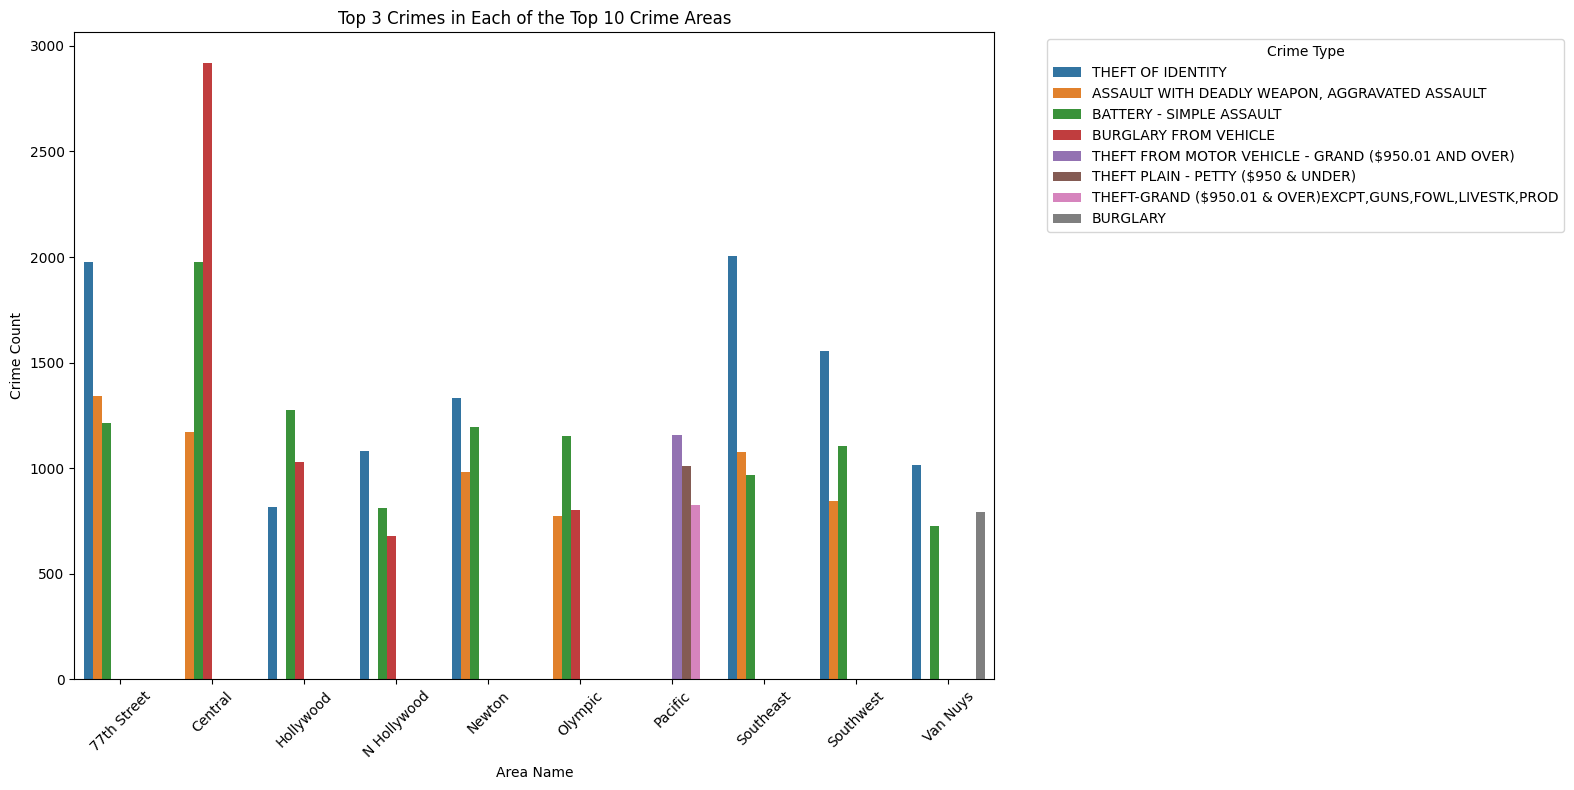

In [71]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=top3_crimes_per_area,
    x='AREA NAME',
    y='Count',
    hue='Crm Cd Desc',
)

plt.title("Top 3 Crimes in Each of the Top 10 Crime Areas")
plt.xlabel("Area Name")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [74]:
# Convert TIME OCC (e.g., 1330 → 13:30)
# Convert TIME OCC to numeric, invalid values become NaN

crimes_df['TIME OCC'] = pd.to_numeric(crimes_df['TIME OCC'], errors='coerce')
crimes_df['Hour'] = crimes_df['TIME OCC'] // 100
crimes_df = crimes_df.dropna(subset=['TIME OCC'])
crimes_df['TIME OCC'] = crimes_df['TIME OCC'].astype(int)

crimes_df['TIME OCC'] = crimes_df['TIME OCC'].apply(lambda x: f"{x:04d}")

crimes_df['Hour'] = crimes_df['TIME OCC'].str[:2].astype(int)


In [75]:
def assign_day_period(hour):
    if 0 <= hour < 6:
        return "(12am-6am)"
    elif 6 <= hour < 12:
        return "(6am-12pm)"
    elif 12 <= hour < 18:
        return "(12pm-6pm)"
    else:
        return "Night (6pm-12am)"

crimes_df['Time of Day'] = crimes_df['Hour'].apply(assign_day_period)


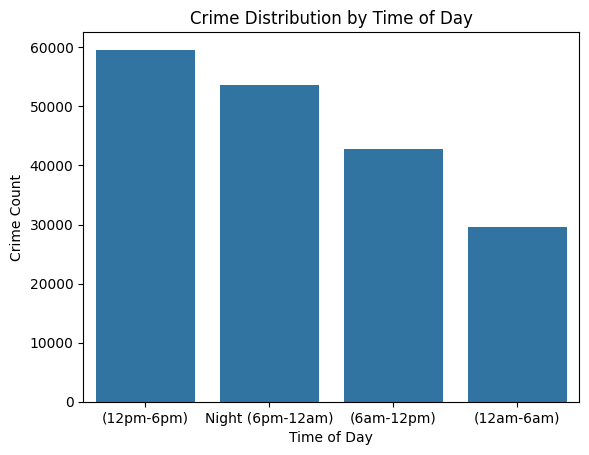

In [76]:
time_counts = crimes_df['Time of Day'].value_counts().reset_index()
time_counts.columns = ['Time of Day', 'Crime Count']

sns.barplot(data=time_counts, x='Time of Day', y='Crime Count')
plt.title("Crime Distribution by Time of Day")
plt.show()


In [77]:
# Count of crimes by victim sex
sex_counts = crimes_df['Vict Sex'].value_counts().reset_index()
sex_counts.columns = ['Victim Sex', 'Crime Count']
sex_counts


,Victim Sex,Crime Count
0,M,93008
1,F,89854
2,X,2812
3,H,30
4,Unkown,11


/tmp/ipykernel_1259247/1812091996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sex_counts, x='Victim Sex', y='Crime Count', palette='pastel')


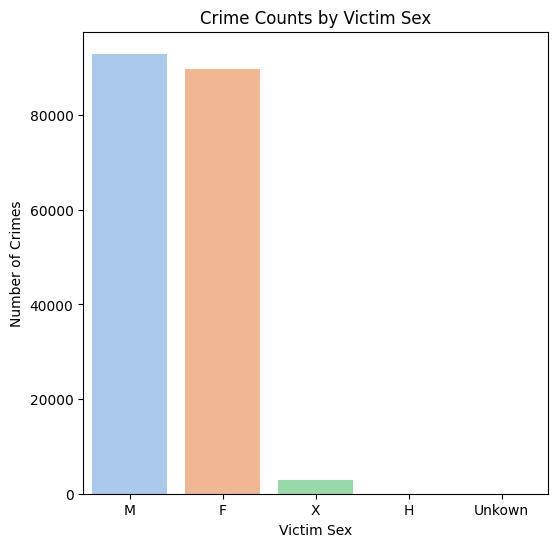

In [78]:

plt.figure(figsize=(6,6))
sns.barplot(data=sex_counts, x='Victim Sex', y='Crime Count', palette='pastel')

plt.title("Crime Counts by Victim Sex")
plt.xlabel("Victim Sex")
plt.ylabel("Number of Crimes")
plt.show()


In [79]:
descent_counts = crimes_df['Vict Descent'].value_counts().reset_index()
descent_counts.columns = ['Victim Descent', 'Crime Count']
descent_counts


,Victim Descent,Crime Count
0,H,74128
1,W,44985
2,B,34931
3,O,16331
4,A,5519
5,X,4548
6,K,1389
7,F,1228
8,C,1210
9,J,433


/tmp/ipykernel_1259247/3721526730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=descent_counts, x='Crime Count', y='Victim Descent', palette='coolwarm')


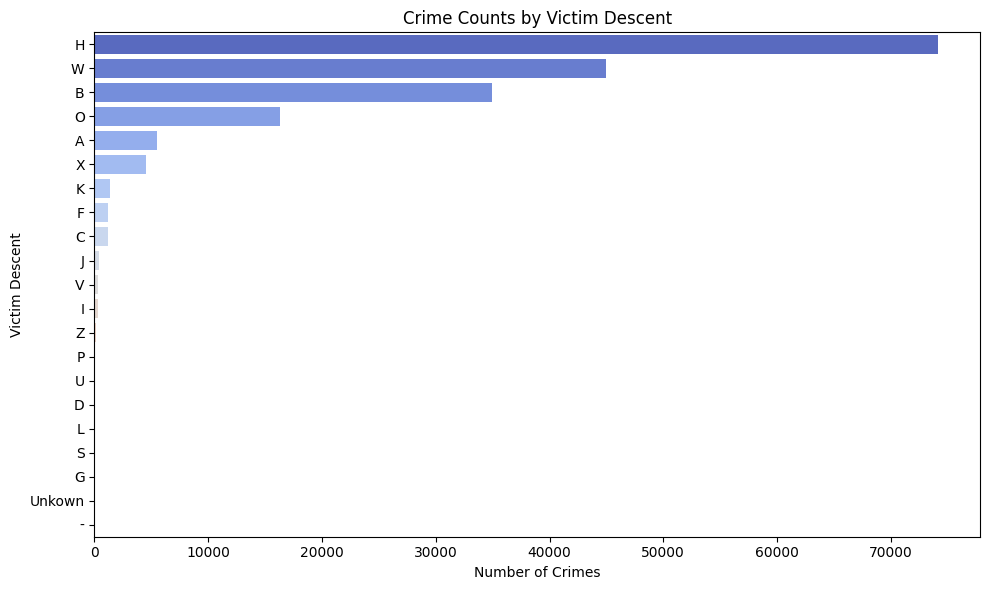

In [80]:
plt.figure(figsize=(10,6))
sns.barplot(data=descent_counts, x='Crime Count', y='Victim Descent', palette='coolwarm')
plt.title("Crime Counts by Victim Descent")
plt.xlabel("Number of Crimes")
plt.ylabel("Victim Descent")
plt.tight_layout()
plt.show()